# Cluster number counts in SNR and redshift

We bin the FLAMINGO L2p8_m9 lightcone clusters in detection significance $q$ and redshift $z$, using the derived catalogue `halo_catalogue_M500c_5e13_zlt3_y0q_arnaudB1.csv`. There, for each halo,
$$y_0 = K\,\frac{Y_{5R500c}}{R_{500c}^2},\qquad K=1.563860,$$
is the intrinsic central Compton-$y$ from the Arnaud/Nagai GNFW shape (hmfast `GNFWPressureProfile`, $r_{\rm out}=5R_{500c}$, no beam, **no hydrostatic bias, $B=1$**; the Battaglia 2012 profile is not used). The significance is
$$q = \frac{y_0}{\sigma_{y_0}(\theta_{500})},\qquad \theta_{500}=\frac{R_{500c}}{D_A(z)},$$
with $\sigma_{y_0}$ read from the sky-averaged szifi noise curve (immf6) at the cluster angular size. The catalogue is full-sky and mass-selected on $M_{500c}>5\times10^{13}\,M_\odot$.

The observable here is the binned count $N(q_i, z_j)$: the number of clusters in significance bin $i$ and redshift bin $j$. We show the joint distribution, the redshift distribution $dN/dz$ above fixed $q$ cuts, and the cumulative count $N(>q)$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Publication-quality plot defaults
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})


from flamingo import paths
from flamingo.catalogue import load_catalogue

CAT = paths.HYDRO / 'catalogue' / 'halo_catalogue_M500c_5e13_zlt3_y0q_arnaudB1.csv'
df = load_catalogue(CAT)
df = df[np.isfinite(df['q'])]
print('clusters', len(df), '| z range', round(df['z'].min(), 3), '-', round(df['z'].max(), 3))
print('q: median %.3f  max %.1f' % (df['q'].median(), df['q'].max()))
for qc in (4.5, 5.0, 6.0):
    print(f'  N(q > {qc}) = {int((df["q"] > qc).sum())}')


clusters 1555542 | z range 0.003 - 2.999
q: median 0.102  max 66.9
  N(q > 4.5) = 2980
  N(q > 5.0) = 2392
  N(q > 6.0) = 1632


## Binned counts $N(q, z)$

Joint histogram of the clusters in redshift and significance. We focus on the detection regime $q>1$; the colour shows $\log_{10}$ of the count per bin.

counts grid (15, 18) | clusters with 1<q, z<3: 43230


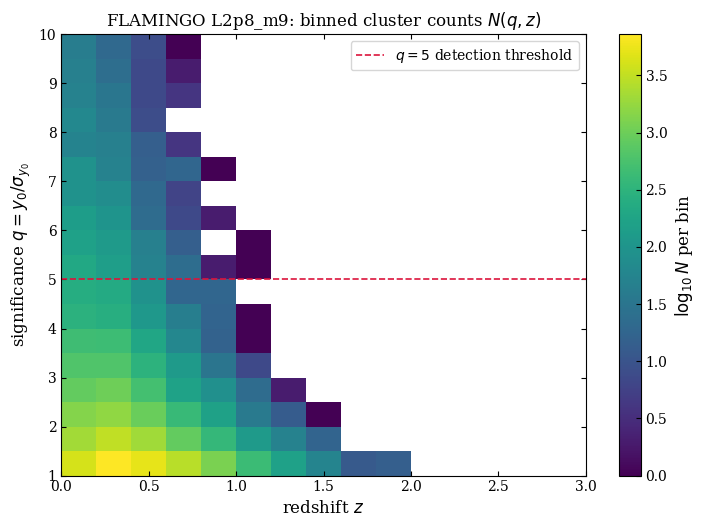

In [2]:
z_edges = np.arange(0.0, 3.0 + 1e-9, 0.2)
q_edges = np.arange(1.0, 10.0 + 1e-9, 0.5)
z_cen = 0.5 * (z_edges[:-1] + z_edges[1:])
q_cen = 0.5 * (q_edges[:-1] + q_edges[1:])

counts, _, _ = np.histogram2d(df['z'].values, df['q'].values, bins=[z_edges, q_edges])
print('counts grid', counts.shape, '| clusters with 1<q, z<3:', int(counts.sum()))

fig, ax = plt.subplots(figsize=(7.4, 5.4))
logN = np.where(counts.T > 0, np.log10(np.where(counts.T > 0, counts.T, 1.0)), np.nan)
pcm = ax.pcolormesh(z_edges, q_edges, logN, cmap='viridis', shading='flat')
ax.axhline(5.0, color='crimson', ls='--', lw=1.2, label=r'$q=5$ detection threshold')
ax.set_xlabel(r'redshift $z$')
ax.set_ylabel(r'significance $q = y_0/\sigma_{y_0}$')
ax.set_title('FLAMINGO L2p8_m9: binned cluster counts $N(q, z)$')
ax.legend(loc='upper right', fontsize=10)
cb = fig.colorbar(pcm, ax=ax)
cb.set_label(r'$\log_{10} N$ per bin')
fig.tight_layout(); plt.show()

## Redshift distribution $dN/dz$ above fixed $q$ cuts

Number of clusters per redshift bin (full sky) for several significance thresholds. Higher $q$ cuts retain fewer, lower-redshift systems.

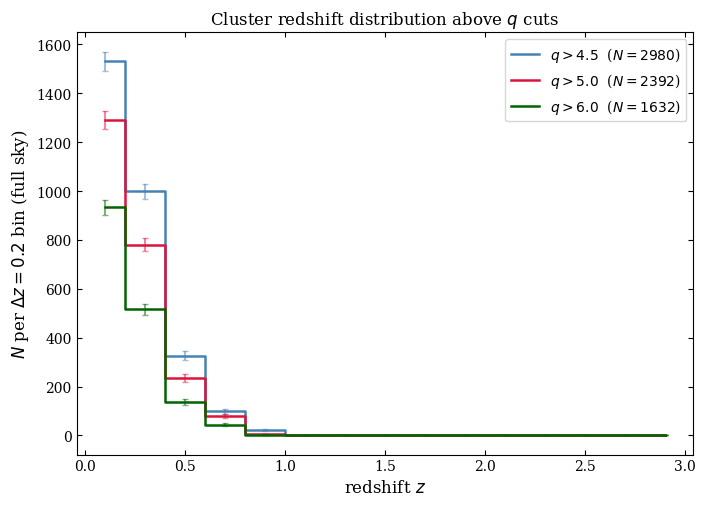

In [3]:
colors = {4.5: 'steelblue', 5.0: 'crimson', 6.0: 'darkgreen'}
fig, ax = plt.subplots(figsize=(7.2, 5.2))
for qc, c in colors.items():
    sel = df[df['q'] > qc]
    N, _ = np.histogram(sel['z'].values, bins=z_edges)
    ax.step(z_cen, N, where='mid', color=c, lw=1.8, label=fr'$q>{qc}$  ($N={len(sel)}$)')
    ax.errorbar(z_cen, N, yerr=np.sqrt(N), fmt='none', ecolor=c, alpha=0.5, capsize=2)
ax.set_xlabel(r'redshift $z$')
ax.set_ylabel(r'$N$ per $\Delta z = 0.2$ bin (full sky)')
ax.set_title('Cluster redshift distribution above $q$ cuts')
ax.legend(fontsize=10)
fig.tight_layout(); plt.show()

## Cumulative significance function $N(>q)$

Number of clusters above significance $q$, the shape of the SZ selection function. The dashed line marks the canonical $q=5$ detection threshold.

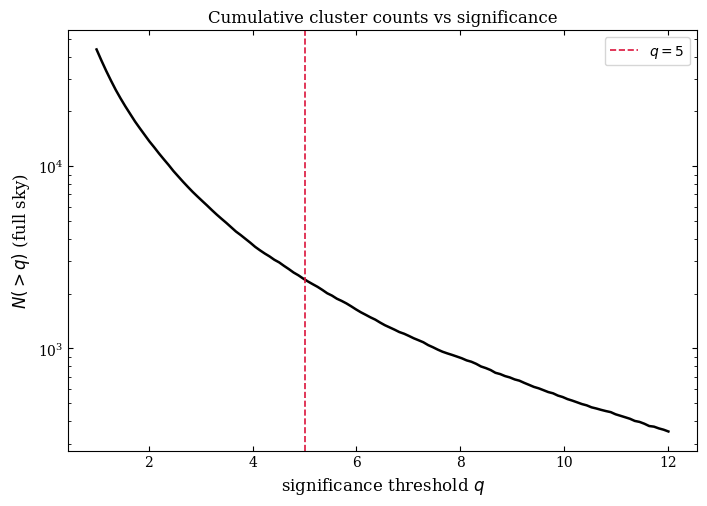

In [4]:
q_grid = np.linspace(1.0, 12.0, 120)
qv = df['q'].values
N_gt = np.array([(qv > qc).sum() for qc in q_grid])

fig, ax = plt.subplots(figsize=(7.2, 5.2))
ax.plot(q_grid, N_gt, color='black', lw=1.8)
ax.axvline(5.0, color='crimson', ls='--', lw=1.2, label=r'$q=5$')
ax.set_yscale('log')
ax.set_xlabel(r'significance threshold $q$')
ax.set_ylabel(r'$N(>q)$ (full sky)')
ax.set_title('Cumulative cluster counts vs significance')
ax.legend(fontsize=10)
fig.tight_layout(); plt.show()

## Masked tSZ power spectrum above $q$ cuts, with completeness theory

We now mask the **detected** clusters (significance $q$ above a threshold $q_{\rm cat}$) out of the Compton-$y$ map and measure the residual (unresolved) tSZ power spectrum, as in notebook 06 but using the $B=1$ significance computed here. For each cut we cut a $R_{\rm mask}\,\theta_{500}$ disc around every detected cluster, **apodize** the mask, subtract the mask-weighted **monopole**, and estimate mask-decoupled bandpowers with **NaMaster** (mode-coupling deconvolution), then deconvolve the HEALPix pixel window.

The matching theory uses the D3A cosmology and the Arnaud A10 GNFW tracer ($B=1$), down-weighting the $(M,z)$ integrand by the scatter **completeness** (probability a halo is *undetected* given log-normal $Y$-$M$ scatter $\sigma_{\ln Y}=0.173$), with the SNR field built from the same GNFW $y_0(M,z)$ and the szifi noise curve. Masking can only remove power, so each masked spectrum lies below the full-sky one.

Cluster counts above each cut (full sky):

In [ ]:
for qc in (50, 20, 10, 5):
    print(f'N(q > {qc}) = {int((df["q"] > qc).sum())}')

N(q > 50) = 2
N(q > 20) = 92
N(q > 10) = 536
N(q > 5) = 2392


### Map side: NaMaster decoupled spectra (full sky + $q$ cuts)

This cell estimates five spectra (full sky and four cluster cuts) at $\ell_{\max}=6000$; each NaMaster mode-coupling deconvolution takes roughly half a minute. The datapoints are cached to `data/nb09_tsz_map_ps.npz` (and the theory to `data/nb09_tsz_theory_ps.npz`), so reruns load them instead of recomputing the expensive mode coupling. Delete those files to force a recompute.

In [6]:
import healpy as hp
from flamingo.maps import read_map
from flamingo.geometry import query_disc_separation, ARCMIN_PER_RAD
from flamingo.powerspectra import apodize, decoupled_dl

LMAX, DELL, R_MASK = 6000, 30, 5.0
Q_CUTS = [50, 20, 10, 5]
MAP_CACHE = paths.DATA / 'nb09_tsz_map_ps.npz'   # cached NaMaster datapoints

if MAP_CACHE.exists():
    # NaMaster mode-coupling is expensive; reuse the saved bandpowers.
    d = np.load(MAP_CACHE)
    ellb = d['ellb']
    dl_map = d['dl_map']
    dl_map_masked = {qc: d[f'dl_q{qc}'] for qc in Q_CUTS}
    print(f'loaded map spectra from {MAP_CACHE.name}')
    for qc in Q_CUTS:
        print(f'q>{qc}: f_sky = {float(d["fsky"][Q_CUTS.index(qc)]):.4f}')
else:
    ymap = read_map(paths.HYDRO_MAP)
    NSIDE = hp.npix2nside(ymap.size)

    # Sky positions live in the original catalogue (yang26-rotated frame); its rows
    # align 1:1 with the derived catalogue, so we pair them with the B=1 q here.
    cat = load_catalogue(paths.HYDRO_CATALOGUE)
    assert len(cat) == len(df), 'row misalignment between original and derived catalogues'
    theta_rot = cat['theta_rot_rad'].values
    phi_rot = cat['phi_rot_rad'].values
    theta500 = df['theta500_arcmin'].values     # B=1 angular size
    qv = df['q'].values

    pwf = hp.pixwin(NSIDE, lmax=LMAX)

    def dl_nmt(weight):
        """Mask-decoupled D_ell (monopole-subtracted) with the pixel window removed."""
        ell_eff, _, cl = decoupled_dl(ymap, weight, delta_ell=DELL, lmax=LMAX)
        pw = np.interp(ell_eff, np.arange(pwf.size), pwf)
        return ell_eff, ell_eff * (ell_eff + 1) / (2 * np.pi) * cl / pw**2

    def build_mask(qcut):
        """Binary mask zeroing a R_MASK*theta500 disc around each detected cluster."""
        mask = np.ones(ymap.size, dtype=np.float64)
        for i in np.where(qv > qcut)[0]:
            r_rad = R_MASK * theta500[i] / ARCMIN_PER_RAD
            pix, _ = query_disc_separation(NSIDE, theta_rot[i], phi_rot[i], r_rad)
            mask[pix] = 0.0
        return mask

    ellb, dl_map = dl_nmt(None)                  # full-sky reference
    dl_map_masked, fsky = {}, []
    for qc in Q_CUTS:
        mk = build_mask(qc)
        fsky.append(mk.mean())
        _, dl_map_masked[qc] = dl_nmt(apodize(mk, aperture_deg=0.5))
        print(f'q>{qc}: masked {int((qv > qc).sum())} clusters, f_sky = {mk.mean():.4f}')

    np.savez(MAP_CACHE, ellb=ellb, dl_map=dl_map, fsky=np.array(fsky),
             **{f'dl_q{qc}': dl_map_masked[qc] for qc in Q_CUTS})
    print(f'saved map spectra to {MAP_CACHE.name}')

loaded map spectra from nb09_tsz_map_ps.npz
q>50: f_sky = 0.9993
q>20: f_sky = 0.9817
q>10: f_sky = 0.9261
q>5: f_sky = 0.8405


### Theory: completeness-weighted Arnaud GNFW ($B=1$)

In [ ]:
import jax.numpy as jnp
from flamingo.catalogue import D3A_COSMOLOGY

THEORY_CACHE = paths.DATA / 'nb09_tsz_theory_ps.npz'   # cached theory datapoints

if THEORY_CACHE.exists():
    d = np.load(THEORY_CACHE)
    ell_np = d['ell']
    dl_th_full = d['dl_full']
    dl_th_masked = {qc: d[f'dl_q{qc}'] for qc in Q_CUTS}
    print(f'loaded theory spectra from {THEORY_CACHE.name}')
else:
    from hmfast.halos import HaloModel, convert_m_delta, MassDefinition
    from hmfast.halos.profiles import GNFWPressureProfile
    from hmfast.tracers import tSZTracer
    from hmfast.utils import Const
    from hmfast.tracers.tsz_completeness import (
        compute_theta500_arcmin, load_sigma_y0_curve, sigma_y0_from_theta,
        conditional_An_undetected,
    )

    # Arnaud A10 GNFW pressure, no hydrostatic bias (B=1), for the power spectrum.
    A10 = dict(P0=8.403, c500=1.177, gamma=0.3081, alpha=1.0510, beta=5.4905)
    B = 1.0
    tracer = tSZTracer(profile=GNFWPressureProfile(**A10, B=B))
    hm = HaloModel(cosmology=D3A_COSMOLOGY)
    SIGMA_LNY = 0.173                       # intrinsic log-normal Y-M scatter

    ell_th = jnp.logspace(1.0, np.log10(LMAX), 40)
    m = jnp.logspace(11.0, 15.5, 60)        # physical Msun
    z = jnp.geomspace(0.001, 3.0, 60)

    # SNR field q(M,z) from the same Arnaud GNFW central y0 and the szifi noise.
    mdef500 = MassDefinition(500, 'critical')
    c_old = hm.concentration.c_delta(hm, m, z)
    m500c = convert_m_delta(hm.cosmology, m, z, hm.mass_definition, mdef500, c_old=c_old)
    r500c = mdef500.r_delta(hm.cosmology, m500c, z)
    h = hm.cosmology.H0 / 100.0
    E_z = jnp.atleast_1d(hm.cosmology.hubble_parameter(z))[None, :] / hm.cosmology.H0
    P_500c = (1.65 * (h / 0.7) ** 2 * E_z ** (8.0 / 3.0)
              * ((m500c * h / B) / (0.7 * 3.0e14)) ** (2.0 / 3.0 + 0.12)
              * (0.7 / h) ** 1.5)
    SIGMA_T_CM2, MEC2_EV, I_SHAPE = 6.6524587e-25, 510998.95, 0.470502095
    y0 = (2.0 * (SIGMA_T_CM2 / MEC2_EV) * A10['P0'] * P_500c
          * (r500c * Const._Mpc_over_m_ * 100.0) * I_SHAPE)
    theta500_th = compute_theta500_arcmin(hm, m, z, B)
    coeff, _ = load_sigma_y0_curve()
    snr = y0 / sigma_y0_from_theta(theta500_th, coeff)

    ell_np = np.asarray(ell_th)
    pref_th = ell_np * (ell_np + 1) / (2 * np.pi)

    # Full-sky (unmasked) theory.
    cl1h = np.asarray(hm.cl_1h(tracer, tracer, l=ell_th, m=m, z=z))
    cl2h = np.asarray(hm.cl_2h(tracer, tracer, l=ell_th, m=m, z=z))
    dl_th_full = pref_th * (cl1h + cl2h)

    # Masked (unresolved) theory per q cut: completeness fraction in [0,1] = conditional
    # moment <A^n 1(undetected)> normalised by <A^n> (n=2 for 1h, n=1 for each 2h bracket).
    norm1 = np.exp(0.5 * (2 * SIGMA_LNY) ** 2)
    norm2 = np.exp(0.5 * (1 * SIGMA_LNY) ** 2)
    dl_th_masked = {}
    for qc in Q_CUTS:
        w1h = conditional_An_undetected(snr, SIGMA_LNY, qc, n_power=2) / norm1
        w2h = conditional_An_undetected(snr, SIGMA_LNY, qc, n_power=1) / norm2
        c1 = np.asarray(hm.cl_1h_masked(tracer, tracer, l=ell_th, m=m, z=z, mask_mz=w1h))
        c2 = np.asarray(hm.cl_2h_masked(tracer, tracer, l=ell_th, m=m, z=z, mask_mz=w2h))
        dl_th_masked[qc] = pref_th * (c1 + c2)

    np.savez(THEORY_CACHE, ell=ell_np, dl_full=dl_th_full,
             **{f'dl_q{qc}': dl_th_masked[qc] for qc in Q_CUTS})
    print(f'saved theory spectra to {THEORY_CACHE.name}')

for qc in Q_CUTS:
    print(f'q>{qc}: theory D_ell@3000 = {float(np.interp(3000, ell_np, dl_th_masked[qc])):.3e}'
          f'   (full sky {float(np.interp(3000, ell_np, dl_th_full)):.3e})')

loaded theory spectra from nb09_tsz_theory_ps.npz
q>50: theory D_ell@3000 = 1.586e-12   (full sky 1.592e-12)
q>20: theory D_ell@3000 = 1.540e-12   (full sky 1.592e-12)
q>10: theory D_ell@3000 = 1.438e-12   (full sky 1.592e-12)
q>5: theory D_ell@3000 = 1.253e-12   (full sky 1.592e-12)


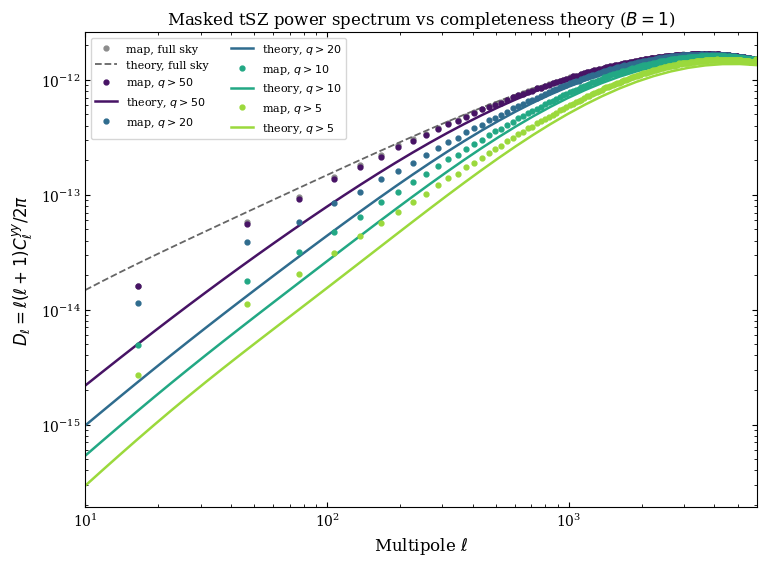

In [8]:
import matplotlib as mpl

cmap = mpl.colormaps['viridis']
qcolors = {50: cmap(0.05), 20: cmap(0.35), 10: cmap(0.60), 5: cmap(0.85)}

fig, ax = plt.subplots(figsize=(7.8, 5.8))
ax.loglog(ellb, dl_map, 'o', ms=3.5, color='0.55', label='map, full sky')
ax.loglog(ell_np, dl_th_full, '--', lw=1.3, color='0.4', label='theory, full sky')
for qc in Q_CUTS:
    ax.loglog(ellb, dl_map_masked[qc], 'o', ms=3.5, color=qcolors[qc],
              label=fr'map, $q>{qc}$')
    ax.loglog(ell_np, dl_th_masked[qc], '-', lw=1.8, color=qcolors[qc],
              label=fr'theory, $q>{qc}$')
ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'$D_\ell = \ell(\ell+1)C_\ell^{yy}/2\pi$')
ax.set_title(r'Masked tSZ power spectrum vs completeness theory ($B=1$)')
ax.set_xlim(10, LMAX)
ax.legend(fontsize=8, ncol=2)
fig.tight_layout(); plt.show()